In [1]:
# CELL 1: Setup & Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All imports successful!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

✓ All imports successful!
NumPy version: 2.5.1
Pandas version: 3.0.5


In [2]:
# CELL 2: Load Raw Data

# Load the 3 CSV files
print("Loading data...")

activity_df = pd.read_csv('../../data/raw/dailyActivity_merged.csv')
sleep_df = pd.read_csv('../../data/raw/sleepDay_merged.csv')
weight_df = pd.read_csv('../../data/raw/weightLogInfo_merged.csv')

print("✓ Data loaded successfully!\n")

print(f"Activity data shape: {activity_df.shape}")
print(f"Sleep data shape: {sleep_df.shape}")
print(f"Weight data shape: {weight_df.shape}")

Loading data...
✓ Data loaded successfully!

Activity data shape: (940, 15)
Sleep data shape: (413, 5)
Weight data shape: (67, 8)


In [3]:
# CELL 3: Explore Activity Data

print("="*60)
print("ACTIVITY DATA EXPLORATION")
print("="*60)

print("\nFirst 5 rows:")
print(activity_df.head())

print("\nColumn names and types:")
print(activity_df.dtypes)

print("\nDataset shape:", activity_df.shape)
print(f"Rows: {activity_df.shape[0]}, Columns: {activity_df.shape[1]}")

print("\nMissing values:")
print(activity_df.isnull().sum())

print("\nDuplicate rows:", activity_df.duplicated().sum())

print("\nBasic statistics:")
print(activity_df.describe())

print("\nTarget variable (Calories) statistics:")
print(activity_df['Calories'].describe())

ACTIVITY DATA EXPLORATION

First 5 rows:
           Id ActivityDate  TotalSteps  TotalDistance  TrackerDistance  \
0  1503960366    4/12/2016       13162           8.50             8.50   
1  1503960366    4/13/2016       10735           6.97             6.97   
2  1503960366    4/14/2016       10460           6.74             6.74   
3  1503960366    4/15/2016        9762           6.28             6.28   
4  1503960366    4/16/2016       12669           8.16             8.16   

   LoggedActivitiesDistance  VeryActiveDistance  ModeratelyActiveDistance  \
0                       0.0                1.88                      0.55   
1                       0.0                1.57                      0.69   
2                       0.0                2.44                      0.40   
3                       0.0                2.14                      1.26   
4                       0.0                2.71                      0.41   

   LightActiveDistance  SedentaryActiveDistance  Ve

In [4]:
# CELL 4: Explore Sleep & Weight Data

print("\n" + "="*60)
print("SLEEP DATA EXPLORATION")
print("="*60)

print("\nFirst 5 rows:")
print(sleep_df.head())

print("\nColumn names and types:")
print(sleep_df.dtypes)

print("\nSleep data shape:", sleep_df.shape)
print("Missing values:")
print(sleep_df.isnull().sum())

print("\nBasic statistics:")
print(sleep_df.describe())

print("\n" + "="*60)
print("WEIGHT DATA EXPLORATION")
print("="*60)

print("\nFirst 5 rows:")
print(weight_df.head())

print("\nColumn names and types:")
print(weight_df.dtypes)

print("\nWeight data shape:", weight_df.shape)
print("Missing values:")
print(weight_df.isnull().sum())

print("\nBasic statistics:")
print(weight_df.describe())


SLEEP DATA EXPLORATION

First 5 rows:
           Id               SleepDay  TotalSleepRecords  TotalMinutesAsleep  \
0  1503960366  4/12/2016 12:00:00 AM                  1                 327   
1  1503960366  4/13/2016 12:00:00 AM                  2                 384   
2  1503960366  4/15/2016 12:00:00 AM                  1                 412   
3  1503960366  4/16/2016 12:00:00 AM                  2                 340   
4  1503960366  4/17/2016 12:00:00 AM                  1                 700   

   TotalTimeInBed  
0             346  
1             407  
2             442  
3             367  
4             712  

Column names and types:
Id                    int64
SleepDay                str
TotalSleepRecords     int64
TotalMinutesAsleep    int64
TotalTimeInBed        int64
dtype: object

Sleep data shape: (413, 5)
Missing values:
Id                    0
SleepDay              0
TotalSleepRecords     0
TotalMinutesAsleep    0
TotalTimeInBed        0
dtype: int64

Basic sta

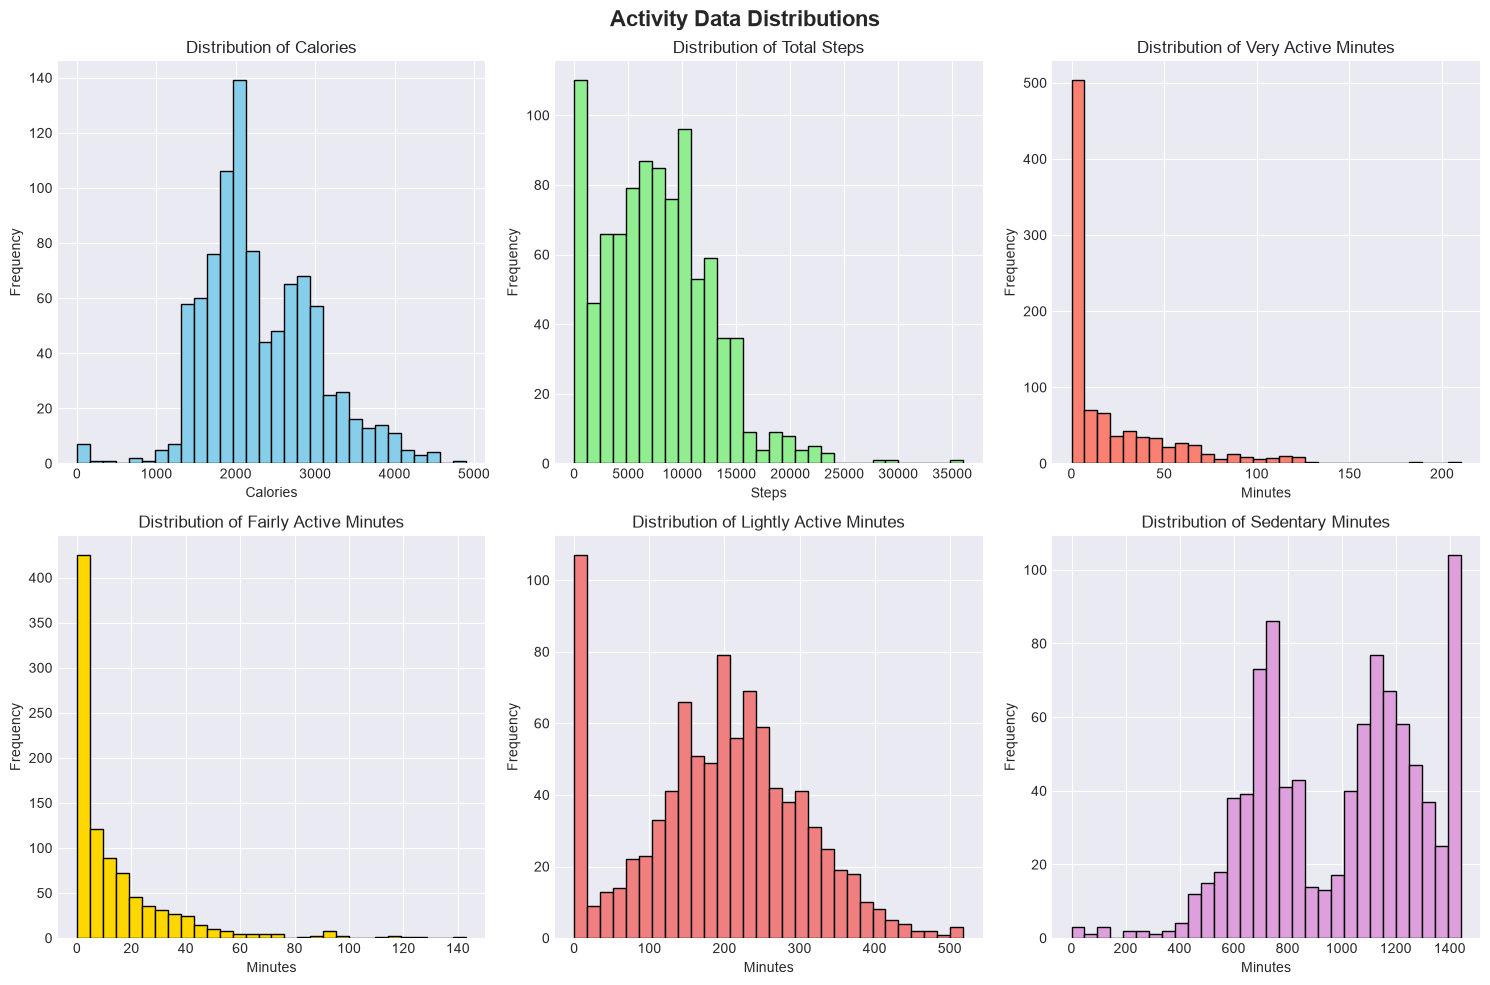

✓ Distribution plots saved!


In [5]:
# CELL 5: Data Distribution - Visualizations

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Activity Data Distributions', fontsize=16, fontweight='bold')

# Calories
axes[0, 0].hist(activity_df['Calories'], bins=30, edgecolor='black', color='skyblue')
axes[0, 0].set_title('Distribution of Calories')
axes[0, 0].set_xlabel('Calories')
axes[0, 0].set_ylabel('Frequency')

# Total Steps
axes[0, 1].hist(activity_df['TotalSteps'], bins=30, edgecolor='black', color='lightgreen')
axes[0, 1].set_title('Distribution of Total Steps')
axes[0, 1].set_xlabel('Steps')
axes[0, 1].set_ylabel('Frequency')

# Very Active Minutes
axes[0, 2].hist(activity_df['VeryActiveMinutes'], bins=30, edgecolor='black', color='salmon')
axes[0, 2].set_title('Distribution of Very Active Minutes')
axes[0, 2].set_xlabel('Minutes')
axes[0, 2].set_ylabel('Frequency')

# Fairly Active Minutes
axes[1, 0].hist(activity_df['FairlyActiveMinutes'], bins=30, edgecolor='black', color='gold')
axes[1, 0].set_title('Distribution of Fairly Active Minutes')
axes[1, 0].set_xlabel('Minutes')
axes[1, 0].set_ylabel('Frequency')

# Lightly Active Minutes
axes[1, 1].hist(activity_df['LightlyActiveMinutes'], bins=30, edgecolor='black', color='lightcoral')
axes[1, 1].set_title('Distribution of Lightly Active Minutes')
axes[1, 1].set_xlabel('Minutes')
axes[1, 1].set_ylabel('Frequency')

# Sedentary Minutes
axes[1, 2].hist(activity_df['SedentaryMinutes'], bins=30, edgecolor='black', color='plum')
axes[1, 2].set_title('Distribution of Sedentary Minutes')
axes[1, 2].set_xlabel('Minutes')
axes[1, 2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("✓ Distribution plots saved!")

In [6]:
# CELL 6: Prepare Data for Merging

# Convert date columns to datetime
activity_df['ActivityDate'] = pd.to_datetime(activity_df['ActivityDate'])
sleep_df['SleepDay'] = pd.to_datetime(sleep_df['SleepDay'])
weight_df['Date'] = pd.to_datetime(weight_df['Date'])

# Create date column (without time) for merging
activity_df['Date'] = activity_df['ActivityDate'].dt.date
sleep_df['Date'] = sleep_df['SleepDay'].dt.date
weight_df['Date'] = weight_df['Date'].dt.date

print("✓ Date columns prepared")
print(f"\nActivity date range: {activity_df['Date'].min()} to {activity_df['Date'].max()}")
print(f"Sleep date range: {sleep_df['Date'].min()} to {sleep_df['Date'].max()}")
print(f"Weight date range: {weight_df['Date'].min()} to {weight_df['Date'].max()}")

✓ Date columns prepared

Activity date range: 2016-04-12 to 2016-05-12
Sleep date range: 2016-04-12 to 2016-05-12
Weight date range: 2016-04-12 to 2016-05-12


In [7]:
# CELL 7: Merge Datasets

print("Merging datasets...")

# Select only necessary columns from sleep
sleep_merge = sleep_df[['Id', 'Date', 'TotalSleepRecords', 'TotalMinutesAsleep', 'TotalTimeInBed']]

# Select only necessary columns from weight
weight_merge = weight_df[['Id', 'Date', 'WeightKg', 'BMI', 'Fat']]

# Merge activity with sleep (left join - keep all activity rows)
merged_df = activity_df.merge(sleep_merge, on=['Id', 'Date'], how='left')

# Merge with weight (left join - keep all activity rows)
merged_df = merged_df.merge(weight_merge, on=['Id', 'Date'], how='left')

print(f"✓ Datasets merged!")
print(f"\nMerged dataset shape: {merged_df.shape}")
print(f"Rows: {merged_df.shape[0]}, Columns: {merged_df.shape[1]}")

print("\nFirst 5 rows of merged data:")
print(merged_df.head())

print("\nMissing values after merge:")
print(merged_df.isnull().sum())

Merging datasets...
✓ Datasets merged!

Merged dataset shape: (943, 22)
Rows: 943, Columns: 22

First 5 rows of merged data:
           Id ActivityDate  TotalSteps  TotalDistance  TrackerDistance  \
0  1503960366   2016-04-12       13162           8.50             8.50   
1  1503960366   2016-04-13       10735           6.97             6.97   
2  1503960366   2016-04-14       10460           6.74             6.74   
3  1503960366   2016-04-15        9762           6.28             6.28   
4  1503960366   2016-04-16       12669           8.16             8.16   

   LoggedActivitiesDistance  VeryActiveDistance  ModeratelyActiveDistance  \
0                       0.0                1.88                      0.55   
1                       0.0                1.57                      0.69   
2                       0.0                2.44                      0.40   
3                       0.0                2.14                      1.26   
4                       0.0                2.

In [8]:
# CELL 8 ALTERNATIVE: More Robust Missing Value Handling

print("="*60)
print("PREPROCESSING - ROBUST VERSION")
print("="*60)

print("\nMissing values before preprocessing:")
missing_before = merged_df.isnull().sum()
print(missing_before[missing_before > 0])

# Select only numerical columns
numerical_cols = merged_df.select_dtypes(include=[np.number]).columns

print("\n" + "-"*60)
print("Strategy: Median Imputation")
print("-"*60)

# Create a copy to avoid SettingWithCopyWarning
imputed_data = merged_df[numerical_cols].copy()

# Fill with median for each column
for col in numerical_cols:
    if imputed_data[col].isnull().sum() > 0:
        median_val = imputed_data[col].median()
        imputed_data[col] = imputed_data[col].fillna(median_val)
        print(f"✓ {col}: Filled {missing_before[col]} NaN values (median = {median_val:.2f})")

# Replace original columns with imputed data
merged_df[numerical_cols] = imputed_data

# Verify
print("\n" + "-"*60)
print("Verification:")
print("-"*60)

missing_after = merged_df.isnull().sum()
print(f"\nMissing values after preprocessing:")
total_missing = missing_after.sum()

if total_missing == 0:
    print("✓ All missing values handled successfully!")
    print("✓ Dataset ready for feature engineering!")
else:
    print(f"⚠️  Warning: {total_missing} missing values remain")
    print(missing_after[missing_after > 0])

PREPROCESSING - ROBUST VERSION

Missing values before preprocessing:
TotalSleepRecords     530
TotalMinutesAsleep    530
TotalTimeInBed        530
WeightKg              876
BMI                   876
Fat                   941
dtype: int64

------------------------------------------------------------
Strategy: Median Imputation
------------------------------------------------------------
✓ TotalSleepRecords: Filled 530 NaN values (median = 1.00)
✓ TotalMinutesAsleep: Filled 530 NaN values (median = 433.00)
✓ TotalTimeInBed: Filled 530 NaN values (median = 463.00)
✓ WeightKg: Filled 876 NaN values (median = 62.50)
✓ BMI: Filled 876 NaN values (median = 24.39)
✓ Fat: Filled 941 NaN values (median = 23.50)

------------------------------------------------------------
Verification:
------------------------------------------------------------

Missing values after preprocessing:
✓ All missing values handled successfully!
✓ Dataset ready for feature engineering!


In [9]:
# CELL 9: Feature Engineering - Create New Features

print("\n" + "="*60)
print("FEATURE ENGINEERING")
print("="*60)

# Feature 1: Total Active Minutes
merged_df['TotalActiveMinutes'] = (
    merged_df['VeryActiveMinutes'] + 
    merged_df['FairlyActiveMinutes'] + 
    merged_df['LightlyActiveMinutes']
)
print("\n✓ Created: TotalActiveMinutes")

# Feature 2: Activity Ratio (Active vs Sedentary)
merged_df['ActivityRatio'] = (
    merged_df['TotalActiveMinutes'] / 
    (merged_df['TotalActiveMinutes'] + merged_df['SedentaryMinutes'] + 1)
)
print("✓ Created: ActivityRatio")

# Feature 3: Very Active Ratio (Out of total active)
merged_df['VeryActiveRatio'] = (
    merged_df['VeryActiveMinutes'] / 
    (merged_df['TotalActiveMinutes'] + 1)
)
print("✓ Created: VeryActiveRatio")

# Feature 4: Sedentary Percentage (Out of day)
merged_df['SedentaryPercentage'] = (
    merged_df['SedentaryMinutes'] / 1440.0  # 1440 minutes in a day
)
print("✓ Created: SedentaryPercentage")

# Feature 5: Activity Sleep Ratio
merged_df['ActivitySleepRatio'] = (
    merged_df['TotalActiveMinutes'] / 
    (merged_df['TotalMinutesAsleep'] + 1)
)
print("✓ Created: ActivitySleepRatio")

# Feature 6: Steps per Active Minute
merged_df['StepsPerActiveMinute'] = (
    merged_df['TotalSteps'] / 
    (merged_df['TotalActiveMinutes'] + 1)
)
print("✓ Created: StepsPerActiveMinute")

# Feature 7: Calories per Step (normalized)
merged_df['CaloriesPerStep'] = (
    merged_df['Calories'] / 
    (merged_df['TotalSteps'] + 1)
)
print("✓ Created: CaloriesPerStep")

print(f"\n✓ Total features after engineering: {len(merged_df.columns) - 5}")  # -5 for date/id columns


FEATURE ENGINEERING

✓ Created: TotalActiveMinutes
✓ Created: ActivityRatio
✓ Created: VeryActiveRatio
✓ Created: SedentaryPercentage
✓ Created: ActivitySleepRatio
✓ Created: StepsPerActiveMinute
✓ Created: CaloriesPerStep

✓ Total features after engineering: 24


In [10]:
# CELL 10: Check Engineered Features

print("\nNew features summary:")
new_features = ['TotalActiveMinutes', 'ActivityRatio', 'VeryActiveRatio', 
                'SedentaryPercentage', 'ActivitySleepRatio', 'StepsPerActiveMinute',
                'CaloriesPerStep']

print(merged_df[new_features].describe())

print("\nNew features correlation with Calories:")
for col in new_features:
    corr = merged_df[col].corr(merged_df['Calories'])
    print(f"{col}: {corr:.4f}")


New features summary:
       TotalActiveMinutes  ActivityRatio  VeryActiveRatio  \
count          943.000000     943.000000       943.000000   
mean           227.893955       0.199887         0.079676   
std            121.893681       0.115530         0.118693   
min              0.000000       0.000000         0.000000   
25%            147.000000       0.124219         0.000000   
50%            248.000000       0.214434         0.015924   
75%            317.500000       0.269701         0.126459   
max            552.000000       0.666667         0.970588   

       SedentaryPercentage  ActivitySleepRatio  StepsPerActiveMinute  \
count           943.000000          943.000000            943.000000   
mean              0.687745            0.582796             83.026797   
std               0.209210            0.463004            670.459860   
min               0.000000            0.000000              0.000000   
25%               0.506250            0.324885             20.78619

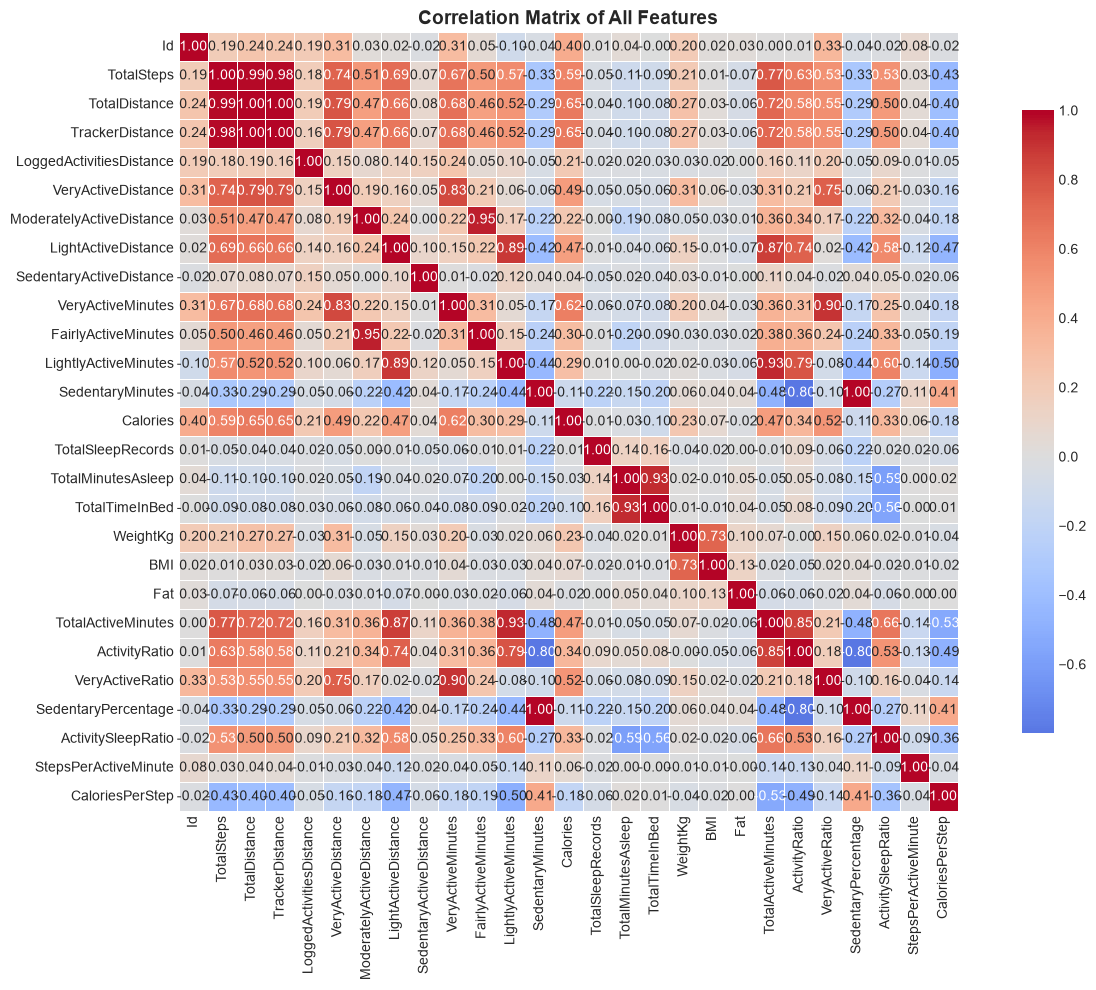

✓ Correlation heatmap saved!

Top 10 features most correlated with Calories:
Calories               1.000000
TrackerDistance        0.646979
TotalDistance          0.646602
VeryActiveMinutes      0.615773
TotalSteps             0.592949
VeryActiveRatio        0.516948
VeryActiveDistance     0.491019
TotalActiveMinutes     0.473789
LightActiveDistance    0.469418
Id                     0.397471
ActivityRatio          0.339995
Name: Calories, dtype: float64


In [11]:
# CELL 11: Correlation Analysis

# Select only numerical columns
numerical_cols = merged_df.select_dtypes(include=[np.number]).columns

# Calculate correlation matrix
correlation_matrix = merged_df[numerical_cols].corr()

# Create correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of All Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Correlation heatmap saved!")

# Show top correlations with Calories
print("\nTop 10 features most correlated with Calories:")
calories_corr = correlation_matrix['Calories'].sort_values(ascending=False)
print(calories_corr.head(11))  # 11 to exclude Calories itself

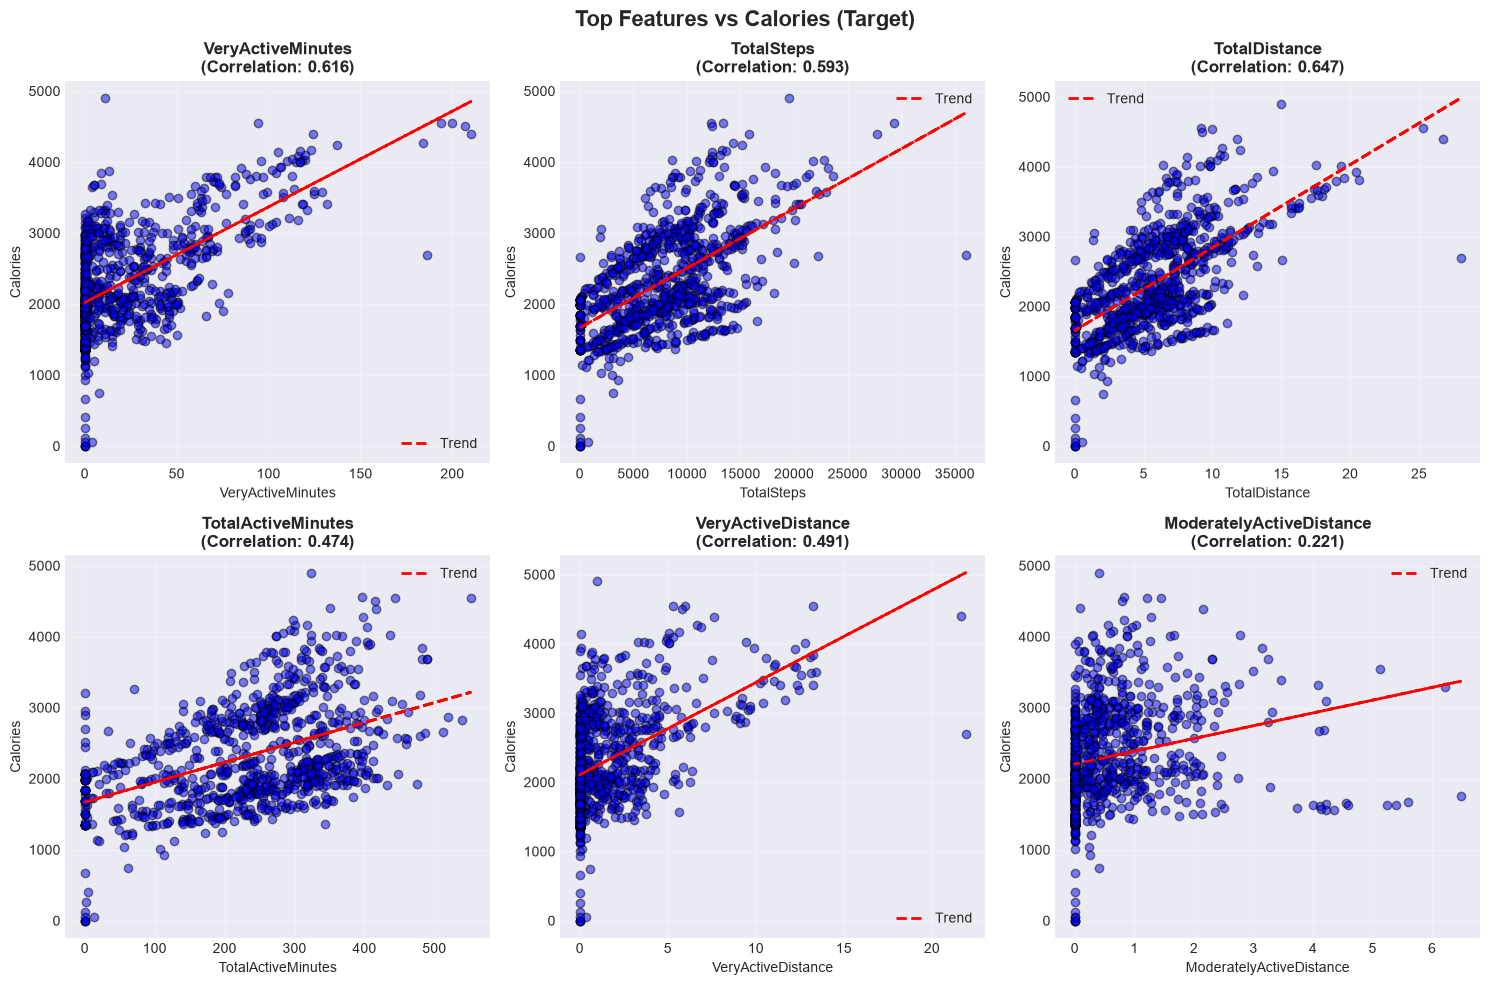

✓ Feature vs Calories plots saved!


In [12]:
# CELL 12: Feature vs Target Visualization

# Select top 6 features by correlation
top_features = ['VeryActiveMinutes', 'TotalSteps', 'TotalDistance', 
                'TotalActiveMinutes', 'VeryActiveDistance', 'ModeratelyActiveDistance']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Top Features vs Calories (Target)', fontsize=16, fontweight='bold')

axes = axes.ravel()

for idx, feature in enumerate(top_features):
    axes[idx].scatter(merged_df[feature], merged_df['Calories'], alpha=0.5, color='blue', edgecolor='black')
    
    # Add trend line
    z = np.polyfit(merged_df[feature], merged_df['Calories'], 1)
    p = np.poly1d(z)
    axes[idx].plot(merged_df[feature], p(merged_df[feature]), "r--", linewidth=2, label='Trend')
    
    corr = merged_df[feature].corr(merged_df['Calories'])
    axes[idx].set_title(f'{feature}\n(Correlation: {corr:.3f})', fontweight='bold')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Calories')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Feature vs Calories plots saved!")

In [13]:
# CELL 13: FIXED - Prepare Final Dataset for Regression

# Select columns to keep
# Drop: date columns, ID (not needed for regression)

columns_to_drop = ['Id', 'ActivityDate', 'Date']  # ← Only these 3 exist!
regression_df = merged_df.drop(columns=columns_to_drop)

print("Final regression dataset shape:", regression_df.shape)
print(f"Rows: {regression_df.shape[0]}, Columns: {regression_df.shape[1]}")

print("\nColumn names:")
print(list(regression_df.columns))

print("\nDataset summary:")
print(regression_df.describe())

# Check for any remaining missing values
print("\nMissing values:")
missing_check = regression_df.isnull().sum()
if missing_check.sum() == 0:
    print("✓ No missing values!")
else:
    print(missing_check[missing_check > 0])

print("\n✓ Final dataset ready for regression!")

Final regression dataset shape: (943, 26)
Rows: 943, Columns: 26

Column names:
['TotalSteps', 'TotalDistance', 'TrackerDistance', 'LoggedActivitiesDistance', 'VeryActiveDistance', 'ModeratelyActiveDistance', 'LightActiveDistance', 'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories', 'TotalSleepRecords', 'TotalMinutesAsleep', 'TotalTimeInBed', 'WeightKg', 'BMI', 'Fat', 'TotalActiveMinutes', 'ActivityRatio', 'VeryActiveRatio', 'SedentaryPercentage', 'ActivitySleepRatio', 'StepsPerActiveMinute', 'CaloriesPerStep']

Dataset summary:
         TotalSteps  TotalDistance  TrackerDistance  LoggedActivitiesDistance  \
count    943.000000     943.000000       943.000000                943.000000   
mean    7652.188759       5.502853         5.488547                  0.110045   
std     5086.532832       3.926509         3.909291                  0.622292   
min        0.000000       0.000000         0.000000               

In [14]:
# CELL 14: Save Processed Data

# Save to CSV
output_path = '../../data/processed/regression_data.csv'
regression_df.to_csv(output_path, index=False)

print(f"✓ Data saved to: {output_path}")
print(f"File size: {regression_df.memory_usage(deep=True).sum() / 1024:.2f} KB")

# Verify it was saved
loaded_df = pd.read_csv(output_path)
print(f"\n✓ Verification - loaded shape: {loaded_df.shape}")

✓ Data saved to: ../../data/processed/regression_data.csv
File size: 191.68 KB

✓ Verification - loaded shape: (943, 26)


In [15]:
# CELL 15: Summary Report

print("\n" + "="*70)
print("NOTEBOOK 01 - EDA & PREPROCESSING - SUMMARY REPORT")
print("="*70)

print(f"""
✓ DATASET LOADED
  - Activity records: {activity_df.shape[0]}
  - Sleep records: {sleep_df.shape[0]}
  - Weight records: {weight_df.shape[0]}

✓ DATASETS MERGED
  - Combined shape: {merged_df.shape}
  - Time period: {merged_df['Date'].min()} to {merged_df['Date'].max()}

✓ MISSING VALUES HANDLED
  - Method: Median imputation
  - Status: All missing values filled

✓ FEATURE ENGINEERING
  - New features created: 7
  - Total features: {regression_df.shape[1]}
  
✓ TARGET VARIABLE
  - Calories (Daily Calorie Burn)
  - Range: {regression_df['Calories'].min():.0f} - {regression_df['Calories'].max():.0f}
  - Mean: {regression_df['Calories'].mean():.0f}
  - Std: {regression_df['Calories'].std():.0f}

✓ TOP 3 CORRELATIONS WITH CALORIES
  1. VeryActiveMinutes: {regression_df['VeryActiveMinutes'].corr(regression_df['Calories']):.4f}
  2. TotalActiveMinutes: {regression_df['TotalActiveMinutes'].corr(regression_df['Calories']):.4f}
  3. TotalDistance: {regression_df['TotalDistance'].corr(regression_df['Calories']):.4f}

✓ OUTPUTS GENERATED
  - Cleaned data: data/processed/regression_data.csv
  - Distribution plots: results/regression/plots/01_distributions.png
  - Correlation heatmap: results/regression/plots/02_correlation_heatmap.png
  - Feature vs Target: results/regression/plots/03_features_vs_calories.png

✓ STATUS: COMPLETE ✓
  Ready for Notebook 02 (Linear Models)
""")

print("="*70)


NOTEBOOK 01 - EDA & PREPROCESSING - SUMMARY REPORT

✓ DATASET LOADED
  - Activity records: 940
  - Sleep records: 413
  - Weight records: 67

✓ DATASETS MERGED
  - Combined shape: (943, 29)
  - Time period: 2016-04-12 to 2016-05-12

✓ MISSING VALUES HANDLED
  - Method: Median imputation
  - Status: All missing values filled

✓ FEATURE ENGINEERING
  - New features created: 7
  - Total features: 26

✓ TARGET VARIABLE
  - Calories (Daily Calorie Burn)
  - Range: 0 - 4900
  - Mean: 2308
  - Std: 721

✓ TOP 3 CORRELATIONS WITH CALORIES
  1. VeryActiveMinutes: 0.6158
  2. TotalActiveMinutes: 0.4738
  3. TotalDistance: 0.6466

✓ OUTPUTS GENERATED
  - Cleaned data: data/processed/regression_data.csv
  - Distribution plots: results/regression/plots/01_distributions.png
  - Correlation heatmap: results/regression/plots/02_correlation_heatmap.png
  - Feature vs Target: results/regression/plots/03_features_vs_calories.png

✓ STATUS: COMPLETE ✓
  Ready for Notebook 02 (Linear Models)



In [16]:
# CELL 16: Import New Libraries for Algorithms 

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib
import warnings
warnings.filterwarnings('ignore')

print("✓ All algorithm libraries imported!")

RANDOM_STATE = 42

✓ All algorithm libraries imported!


In [17]:
# CELL 17: Load Preprocessed Data from Cell 14

print("\n✓ Loading preprocessed regression_data.csv from Cell 14...")

df = pd.read_csv('../../data/processed/regression_data.csv')

# Prepare X and y
X = df.drop('Calories', axis=1)
y = df['Calories']

print(f"✓ Data: {X.shape[0]} samples, {X.shape[1]} features")

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✓ Train/Test Split: {X_train.shape[0]} / {X_test.shape[0]}")


✓ Loading preprocessed regression_data.csv from Cell 14...
✓ Data: 943 samples, 25 features
✓ Train/Test Split: 754 / 189


In [18]:
# CELL 18: Algorithm 1 - Linear Regression

print("\n" + "="*80)
print("ALGORITHM 1: LINEAR REGRESSION")
print("="*80)

model_1 = LinearRegression()
model_1.fit(X_train_scaled, y_train)

y_train_pred_1 = model_1.predict(X_train_scaled)
y_test_pred_1 = model_1.predict(X_test_scaled)

r2_train_1 = r2_score(y_train, y_train_pred_1)
r2_test_1 = r2_score(y_test, y_test_pred_1)
rmse_1 = np.sqrt(mean_squared_error(y_test, y_test_pred_1))
mae_1 = mean_absolute_error(y_test, y_test_pred_1)
cv_r2_1 = cross_val_score(model_1, X_train_scaled, y_train, cv=5, scoring='r2').mean()

print(f"\nTrain R²: {r2_train_1:.4f} | Test R²: {r2_test_1:.4f}")
print(f"RMSE: {rmse_1:.2f} | MAE: {mae_1:.2f} | CV R²: {cv_r2_1:.4f}")

joblib.dump(model_1, '../../models/regression/linear_regression.pkl')
print(f"✓ Model saved: 01_linear_regression.pkl")

algo_1 = {'Algorithm': 'Linear Regression', 'Member': 'M1',
          'R2': r2_test_1, 'RMSE': rmse_1, 'MAE': mae_1, 'CV_R2': cv_r2_1, 'Train_R2': r2_train_1}


ALGORITHM 1: LINEAR REGRESSION

Train R²: 0.8060 | Test R²: 0.7262
RMSE: 379.10 | MAE: 286.32 | CV R²: 0.7805
✓ Model saved: 01_linear_regression.pkl


In [19]:
# CELL 19: Algorithm 2 - Ridge Regression (GridSearchCV - C3 Requirement)

print("\n" + "="*80)
print("ALGORITHM 2: RIDGE REGRESSION (with GridSearchCV)")
print("="*80)

# C3: Hyperparameter Tuning using GridSearchCV
print("\nTuning alpha parameter with GridSearchCV...")
param_grid_ridge = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
ridge_grid = GridSearchCV(Ridge(random_state=RANDOM_STATE), param_grid_ridge, cv=5, scoring='r2', n_jobs=-1)
ridge_grid.fit(X_train_scaled, y_train)

print(f"Best alpha: {ridge_grid.best_params_['alpha']} (CV R² = {ridge_grid.best_score_:.4f})")

model_2 = ridge_grid.best_estimator_

y_train_pred_2 = model_2.predict(X_train_scaled)
y_test_pred_2 = model_2.predict(X_test_scaled)

r2_train_2 = r2_score(y_train, y_train_pred_2)
r2_test_2 = r2_score(y_test, y_test_pred_2)
rmse_2 = np.sqrt(mean_squared_error(y_test, y_test_pred_2))
mae_2 = mean_absolute_error(y_test, y_test_pred_2)

# C3: Report improvement
improvement_ridge = ((r2_test_2 - r2_test_1) / r2_test_1) * 100

print(f"\nTrain R²: {r2_train_2:.4f} | Test R²: {r2_test_2:.4f}")
print(f"RMSE: {rmse_2:.2f} | MAE: {mae_2:.2f}")
print(f"Improvement vs Linear: {improvement_ridge:+.2f}%")

joblib.dump(model_2, '../../models/regression/ridge_regression.pkl')
print(f"✓ Model saved: 02_ridge_regression.pkl")

algo_2 = {'Algorithm': 'Ridge Regression', 'Member': 'M1',
          'R2': r2_test_2, 'RMSE': rmse_2, 'MAE': mae_2, 'CV_R2': ridge_grid.best_score_, 'Train_R2': r2_train_2,
          'Best_Param': ridge_grid.best_params_['alpha']}


ALGORITHM 2: RIDGE REGRESSION (with GridSearchCV)

Tuning alpha parameter with GridSearchCV...
Best alpha: 0.1 (CV R² = 0.7820)

Train R²: 0.8058 | Test R²: 0.7281
RMSE: 377.80 | MAE: 285.89
Improvement vs Linear: +0.26%
✓ Model saved: 02_ridge_regression.pkl


In [20]:
# CELL 20: Algorithm 3 - Lasso Regression (GridSearchCV - C3 Requirement)

print("\n" + "="*80)
print("ALGORITHM 3: LASSO REGRESSION (with GridSearchCV)")
print("="*80)

# C3: Hyperparameter Tuning using GridSearchCV
print("\nTuning alpha parameter with GridSearchCV...")
param_grid_lasso = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}
lasso_grid = GridSearchCV(Lasso(random_state=RANDOM_STATE, max_iter=5000), param_grid_lasso, cv=5, scoring='r2', n_jobs=-1)
lasso_grid.fit(X_train_scaled, y_train)

print(f"Best alpha: {lasso_grid.best_params_['alpha']} (CV R² = {lasso_grid.best_score_:.4f})")

model_3 = lasso_grid.best_estimator_

y_train_pred_3 = model_3.predict(X_train_scaled)
y_test_pred_3 = model_3.predict(X_test_scaled)

r2_train_3 = r2_score(y_train, y_train_pred_3)
r2_test_3 = r2_score(y_test, y_test_pred_3)
rmse_3 = np.sqrt(mean_squared_error(y_test, y_test_pred_3))
mae_3 = mean_absolute_error(y_test, y_test_pred_3)

# C3: Report feature selection
n_features_selected = np.sum(model_3.coef_ != 0)
n_features_total = len(model_3.coef_)

print(f"\nTrain R²: {r2_train_3:.4f} | Test R²: {r2_test_3:.4f}")
print(f"RMSE: {rmse_3:.2f} | MAE: {mae_3:.2f}")
print(f"Features selected: {n_features_selected}/{n_features_total}")

joblib.dump(model_3, '../../models/regression/lasso_regression.pkl')
print(f"✓ Model saved: 03_lasso_regression.pkl")

algo_3 = {'Algorithm': 'Lasso Regression', 'Member': 'M1',
          'R2': r2_test_3, 'RMSE': rmse_3, 'MAE': mae_3, 'CV_R2': lasso_grid.best_score_, 'Train_R2': r2_train_3,
          'Best_Param': lasso_grid.best_params_['alpha']}


ALGORITHM 3: LASSO REGRESSION (with GridSearchCV)

Tuning alpha parameter with GridSearchCV...
Best alpha: 1 (CV R² = 0.7833)

Train R²: 0.8049 | Test R²: 0.7308
RMSE: 375.92 | MAE: 283.85
Features selected: 23/25
✓ Model saved: 03_lasso_regression.pkl


In [21]:
# CELL 21: Algorithm 4 - ElasticNet

print("\n" + "="*80)
print("ALGORITHM 4: ELASTICNET")
print("="*80)

best_score_en = -np.inf
model_4 = None

for alpha in [0.001, 0.01, 0.1, 1, 10]:
    for l1_ratio in [0.1, 0.5, 0.9]:
        en = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=RANDOM_STATE, max_iter=5000)
        en.fit(X_train_scaled, y_train)
        cv_score = cross_val_score(en, X_train_scaled, y_train, cv=5, scoring='r2').mean()
        if cv_score > best_score_en:
            best_score_en = cv_score
            best_alpha_en = alpha
            best_l1_en = l1_ratio
            model_4 = en

y_train_pred_4 = model_4.predict(X_train_scaled)
y_test_pred_4 = model_4.predict(X_test_scaled)

r2_train_4 = r2_score(y_train, y_train_pred_4)
r2_test_4 = r2_score(y_test, y_test_pred_4)
rmse_4 = np.sqrt(mean_squared_error(y_test, y_test_pred_4))
mae_4 = mean_absolute_error(y_test, y_test_pred_4)

print(f"Best params: alpha={best_alpha_en}, l1_ratio={best_l1_en} (CV R² = {best_score_en:.4f})")
print(f"\nTrain R²: {r2_train_4:.4f} | Test R²: {r2_test_4:.4f}")
print(f"RMSE: {rmse_4:.2f} | MAE: {mae_4:.2f}")

joblib.dump(model_4, '../../models/regression/elasticnet.pkl')
print(f"✓ Model saved: 04_elasticnet.pkl")

algo_4 = {'Algorithm': 'ElasticNet', 'Member': 'M1',
          'R2': r2_test_4, 'RMSE': rmse_4, 'MAE': mae_4, 'CV_R2': best_score_en, 'Train_R2': r2_train_4}


ALGORITHM 4: ELASTICNET
Best params: alpha=0.001, l1_ratio=0.5 (CV R² = 0.7823)

Train R²: 0.8052 | Test R²: 0.7307
RMSE: 375.99 | MAE: 284.43
✓ Model saved: 04_elasticnet.pkl


In [22]:
# CELL 22: Algorithm 5 - Polynomial Regression

print("\n" + "="*80)
print("ALGORITHM 5: POLYNOMIAL REGRESSION (Degree 2)")
print("="*80)

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

model_5 = LinearRegression()
model_5.fit(X_train_poly, y_train)

y_train_pred_5 = model_5.predict(X_train_poly)
y_test_pred_5 = model_5.predict(X_test_poly)

r2_train_5 = r2_score(y_train, y_train_pred_5)
r2_test_5 = r2_score(y_test, y_test_pred_5)
rmse_5 = np.sqrt(mean_squared_error(y_test, y_test_pred_5))
mae_5 = mean_absolute_error(y_test, y_test_pred_5)
cv_r2_5 = cross_val_score(model_5, X_train_poly, y_train, cv=5, scoring='r2').mean()

print(f"Features: {X_train_scaled.shape[1]} → {X_train_poly.shape[1]}")
print(f"Train R²: {r2_train_5:.4f} | Test R²: {r2_test_5:.4f}")
print(f"RMSE: {rmse_5:.2f} | MAE: {mae_5:.2f}")

joblib.dump(model_5, '../../models/regression/polynomial_regression.pkl')
joblib.dump(poly, '../../models/regression/polynomial_features.pkl')
print(f"✓ Model saved: 05_polynomial_regression.pkl")

algo_5 = {'Algorithm': 'Polynomial Regression', 'Member': 'M2',
          'R2': r2_test_5, 'RMSE': rmse_5, 'MAE': mae_5, 'CV_R2': cv_r2_5, 'Train_R2': r2_train_5}


ALGORITHM 5: POLYNOMIAL REGRESSION (Degree 2)
Features: 25 → 350
Train R²: 0.9934 | Test R²: -949.7133
RMSE: 22340.38 | MAE: 1763.55
✓ Model saved: 05_polynomial_regression.pkl


In [23]:
# CELL 23: Algorithm 6 - Decision Tree Regressor

print("\n" + "="*80)
print("ALGORITHM 6: DECISION TREE REGRESSOR")
print("="*80)

best_score_tree = -np.inf
model_6 = None

for depth in [3, 5, 7, 10, 15, 20]:
    tree = DecisionTreeRegressor(max_depth=depth, random_state=RANDOM_STATE, min_samples_split=5)
    tree.fit(X_train, y_train)
    cv_score = cross_val_score(tree, X_train, y_train, cv=5, scoring='r2').mean()
    if cv_score > best_score_tree:
        best_score_tree = cv_score
        best_depth = depth
        model_6 = tree

y_train_pred_6 = model_6.predict(X_train)
y_test_pred_6 = model_6.predict(X_test)

r2_train_6 = r2_score(y_train, y_train_pred_6)
r2_test_6 = r2_score(y_test, y_test_pred_6)
rmse_6 = np.sqrt(mean_squared_error(y_test, y_test_pred_6))
mae_6 = mean_absolute_error(y_test, y_test_pred_6)

print(f"Best depth: {best_depth} (CV R² = {best_score_tree:.4f})")
print(f"Train R²: {r2_train_6:.4f} | Test R²: {r2_test_6:.4f}")
print(f"RMSE: {rmse_6:.2f} | MAE: {mae_6:.2f}")

joblib.dump(model_6, '../../models/regression/decision_tree.pkl')
print(f"✓ Model saved: 06_decision_tree.pkl")

algo_6 = {'Algorithm': 'Decision Tree', 'Member': 'M2',
          'R2': r2_test_6, 'RMSE': rmse_6, 'MAE': mae_6, 'CV_R2': best_score_tree, 'Train_R2': r2_train_6}


ALGORITHM 6: DECISION TREE REGRESSOR
Best depth: 15 (CV R² = 0.8185)
Train R²: 0.9900 | Test R²: 0.8738
RMSE: 257.40 | MAE: 160.55
✓ Model saved: 06_decision_tree.pkl


In [24]:
# CELL 24: Algorithm 7 - Random Forest Regressor

print("\n" + "="*80)
print("ALGORITHM 7: RANDOM FOREST REGRESSOR")
print("="*80)

best_score_rf = -np.inf
model_7 = None

for n_est in [50, 100, 200]:
    for max_d in [5, 10, 15]:
        rf = RandomForestRegressor(n_estimators=n_est, max_depth=max_d, random_state=RANDOM_STATE, n_jobs=-1)
        rf.fit(X_train, y_train)
        cv_score = cross_val_score(rf, X_train, y_train, cv=5, scoring='r2').mean()
        if cv_score > best_score_rf:
            best_score_rf = cv_score
            best_n_est = n_est
            best_max_d = max_d
            model_7 = rf

y_train_pred_7 = model_7.predict(X_train)
y_test_pred_7 = model_7.predict(X_test)

r2_train_7 = r2_score(y_train, y_train_pred_7)
r2_test_7 = r2_score(y_test, y_test_pred_7)
rmse_7 = np.sqrt(mean_squared_error(y_test, y_test_pred_7))
mae_7 = mean_absolute_error(y_test, y_test_pred_7)

print(f"Best params: n_estimators={best_n_est}, max_depth={best_max_d} (CV R² = {best_score_rf:.4f})")
print(f"Train R²: {r2_train_7:.4f} | Test R²: {r2_test_7:.4f}")
print(f"RMSE: {rmse_7:.2f} | MAE: {mae_7:.2f}")

joblib.dump(model_7, '../../models/regression/random_forest.pkl')
print(f"✓ Model saved: random_forest.pkl")

algo_7 = {'Algorithm': 'Random Forest', 'Member': 'M2',
          'R2': r2_test_7, 'RMSE': rmse_7, 'MAE': mae_7, 'CV_R2': best_score_rf, 'Train_R2': r2_train_7}

# Store for feature importance plot (C4)
best_model_7 = model_7


ALGORITHM 7: RANDOM FOREST REGRESSOR
Best params: n_estimators=200, max_depth=15 (CV R² = 0.9093)
Train R²: 0.9883 | Test R²: 0.9393
RMSE: 178.52 | MAE: 122.99
✓ Model saved: random_forest.pkl


In [25]:
# CELL 25: Algorithm 8 - Gradient Boosting Regressor

print("\n" + "="*80)
print("ALGORITHM 8: GRADIENT BOOSTING REGRESSOR")
print("="*80)

best_score_gb = -np.inf
model_8 = None

for lr in [0.001, 0.01, 0.1]:
    for n_est in [50, 100, 200]:
        gb = GradientBoostingRegressor(learning_rate=lr, n_estimators=n_est, random_state=RANDOM_STATE, max_depth=5)
        gb.fit(X_train, y_train)
        cv_score = cross_val_score(gb, X_train, y_train, cv=5, scoring='r2').mean()
        if cv_score > best_score_gb:
            best_score_gb = cv_score
            best_lr = lr
            best_n_est_gb = n_est
            model_8 = gb

y_train_pred_8 = model_8.predict(X_train)
y_test_pred_8 = model_8.predict(X_test)

r2_train_8 = r2_score(y_train, y_train_pred_8)
r2_test_8 = r2_score(y_test, y_test_pred_8)
rmse_8 = np.sqrt(mean_squared_error(y_test, y_test_pred_8))
mae_8 = mean_absolute_error(y_test, y_test_pred_8)

print(f"Best params: learning_rate={best_lr}, n_estimators={best_n_est_gb} (CV R² = {best_score_gb:.4f})")
print(f"Train R²: {r2_train_8:.4f} | Test R²: {r2_test_8:.4f}")
print(f"RMSE: {rmse_8:.2f} | MAE: {mae_8:.2f}")

joblib.dump(model_8, '../../models/regression/gradient_boosting.pkl')
print(f"✓ Model saved: 08_gradient_boosting.pkl")

algo_8 = {'Algorithm': 'Gradient Boosting', 'Member': 'M3',
          'R2': r2_test_8, 'RMSE': rmse_8, 'MAE': mae_8, 'CV_R2': best_score_gb, 'Train_R2': r2_train_8}


ALGORITHM 8: GRADIENT BOOSTING REGRESSOR
Best params: learning_rate=0.1, n_estimators=200 (CV R² = 0.9337)
Train R²: 0.9994 | Test R²: 0.9563
RMSE: 151.44 | MAE: 104.28
✓ Model saved: 08_gradient_boosting.pkl


In [26]:
# CELL 26: Algorithm 9 - Support Vector Regressor (SVR)

print("\n" + "="*80)
print("ALGORITHM 9: SUPPORT VECTOR REGRESSOR")
print("="*80)

best_score_svr = -np.inf
model_9 = None

for C in [0.1, 1, 10, 100]:
    for eps in [0.01, 0.1, 0.5]:
        svr = SVR(kernel='rbf', C=C, epsilon=eps)
        svr.fit(X_train_scaled, y_train)
        cv_score = cross_val_score(svr, X_train_scaled, y_train, cv=5, scoring='r2').mean()
        if cv_score > best_score_svr:
            best_score_svr = cv_score
            best_C_svr = C
            best_eps_svr = eps
            model_9 = svr

y_train_pred_9 = model_9.predict(X_train_scaled)
y_test_pred_9 = model_9.predict(X_test_scaled)

r2_train_9 = r2_score(y_train, y_train_pred_9)
r2_test_9 = r2_score(y_test, y_test_pred_9)
rmse_9 = np.sqrt(mean_squared_error(y_test, y_test_pred_9))
mae_9 = mean_absolute_error(y_test, y_test_pred_9)

print(f"Best params: C={best_C_svr}, epsilon={best_eps_svr} (CV R² = {best_score_svr:.4f})")
print(f"Train R²: {r2_train_9:.4f} | Test R²: {r2_test_9:.4f}")
print(f"RMSE: {rmse_9:.2f} | MAE: {mae_9:.2f}")

joblib.dump(model_9, '../../models/regression/svr.pkl')
print(f"✓ Model saved: 09_svr.pkl")

algo_9 = {'Algorithm': 'Support Vector Regressor', 'Member': 'M3',
          'R2': r2_test_9, 'RMSE': rmse_9, 'MAE': mae_9, 'CV_R2': best_score_svr, 'Train_R2': r2_train_9}


ALGORITHM 9: SUPPORT VECTOR REGRESSOR
Best params: C=100, epsilon=0.5 (CV R² = 0.4949)
Train R²: 0.5714 | Test R²: 0.5514
RMSE: 485.27 | MAE: 363.23
✓ Model saved: 09_svr.pkl


In [27]:
# CELL 27: Algorithm 10 - K-Nearest Neighbors

print("\n" + "="*80)
print("ALGORITHM 10: K-NEAREST NEIGHBORS")
print("="*80)

best_score_knn = -np.inf
model_10 = None

for k in [3, 5, 7, 9, 11, 15]:
    knn = KNeighborsRegressor(n_neighbors=k, weights='distance')
    knn.fit(X_train_scaled, y_train)
    cv_score = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='r2').mean()
    if cv_score > best_score_knn:
        best_score_knn = cv_score
        best_k = k
        model_10 = knn

y_train_pred_10 = model_10.predict(X_train_scaled)
y_test_pred_10 = model_10.predict(X_test_scaled)

r2_train_10 = r2_score(y_train, y_train_pred_10)
r2_test_10 = r2_score(y_test, y_test_pred_10)
rmse_10 = np.sqrt(mean_squared_error(y_test, y_test_pred_10))
mae_10 = mean_absolute_error(y_test, y_test_pred_10)

print(f"Best k: {best_k} (CV R² = {best_score_knn:.4f})")
print(f"Train R²: {r2_train_10:.4f} | Test R²: {r2_test_10:.4f}")
print(f"RMSE: {rmse_10:.2f} | MAE: {mae_10:.2f}")

joblib.dump(model_10, '../../models/regression/knn.pkl')
print(f"✓ Model saved: 10_knn.pkl")

algo_10 = {'Algorithm': 'K-Nearest Neighbors', 'Member': 'M3',
           'R2': r2_test_10, 'RMSE': rmse_10, 'MAE': mae_10, 'CV_R2': best_score_knn, 'Train_R2': r2_train_10}


ALGORITHM 10: K-NEAREST NEIGHBORS
Best k: 3 (CV R² = 0.6451)
Train R²: 1.0000 | Test R²: 0.7269
RMSE: 378.64 | MAE: 267.92
✓ Model saved: 10_knn.pkl


In [28]:
print("\n" + "=" * 80)
print("C2: COMPARATIVE EVALUATION - ALL 10 ALGORITHMS")
print("=" * 80)

print(f"\n1️⃣ LOADING ALL ALGORITHM RESULTS FROM MEMORY...")

# Combine all results from Cells 16-25 (10 algorithms)
results = [algo_1, algo_2, algo_3, algo_4, algo_5, algo_6, algo_7, algo_8, algo_9, algo_10]

print(f"   ✅ All {len(results)} algorithms loaded from memory\n")

# Create DataFrame
results_df = pd.DataFrame(results)

# Sort by R² Score (descending)
print(f"2️⃣ SORTING BY R² SCORE...\n")

results_df = results_df.sort_values('R2', ascending=False).reset_index(drop=True)
results_df['Rank'] = range(1, len(results_df) + 1)

print(f"   ✅ Algorithms ranked by R² Score\n")

# ============================================================================
# MASTER COMPARISON TABLE
# ============================================================================

print("=" * 130)
print("MASTER COMPARISON TABLE - ALL 10 REGRESSION ALGORITHMS")
print("=" * 130)
print()
print(results_df.to_string(index=False))
print()
print("=" * 130)

# ============================================================================
# DETAILED RANKING BY DIFFERENT METRICS
# ============================================================================

print(f"\n3️⃣ DETAILED RANKING BY DIFFERENT METRICS:\n")

print("🏆 RANKING BY R² SCORE (Coefficient of Determination - Higher is Better):")
print("─" * 80)
r2_sorted = results_df.sort_values('R2', ascending=False)
for idx, row in r2_sorted.iterrows():
    print(f"   {int(row['Rank'])}. {row['Algorithm']:<35} R²: {row['R2']:>8.4f}")

print("\n🏆 RANKING BY RMSE (Root Mean Squared Error - Lower is Better):")
print("─" * 80)
rmse_sorted = results_df.sort_values('RMSE')
for idx, row in rmse_sorted.iterrows():
    print(f"   {row['Algorithm']:<35} RMSE: {row['RMSE']:>8.4f}")

print("\n🏆 RANKING BY MAE (Mean Absolute Error - Lower is Better):")
print("─" * 80)
mae_sorted = results_df.sort_values('MAE')
for idx, row in mae_sorted.iterrows():
    print(f"   {row['Algorithm']:<35} MAE: {row['MAE']:>8.4f}")

print("\n🏆 RANKING BY CV_R² (Cross-Validation R² - Higher is Better):")
print("─" * 80)
cv_sorted = results_df.sort_values('CV_R2', ascending=False)
for idx, row in cv_sorted.iterrows():
    print(f"   {row['Algorithm']:<35} CV_R²: {row['CV_R2']:>8.4f}")

print("\n🏆 RANKING BY TRAIN_R² (Training R² - Higher is Better):")
print("─" * 80)
train_sorted = results_df.sort_values('Train_R2', ascending=False)
for idx, row in train_sorted.iterrows():
    print(f"   {row['Algorithm']:<35} Train_R²: {row['Train_R2']:>8.4f}")

# ============================================================================
# SUMMARY STATISTICS
# ============================================================================

print(f"\n4️⃣ SUMMARY STATISTICS:\n")

print(f"   TEST R² SCORE STATISTICS:")
print(f"   ├─ Average:  {results_df['R2'].mean():.4f}")
print(f"   ├─ Best:     {results_df['R2'].max():.4f} ({results_df.iloc[0]['Algorithm']})")
print(f"   ├─ Worst:    {results_df['R2'].min():.4f}")
print(f"   └─ Range:    {results_df['R2'].max() - results_df['R2'].min():.4f}")

print(f"\n   CROSS-VALIDATION R² STATISTICS:")
print(f"   ├─ Average:  {results_df['CV_R2'].mean():.4f}")
print(f"   ├─ Best:     {results_df['CV_R2'].max():.4f}")
print(f"   ├─ Worst:    {results_df['CV_R2'].min():.4f}")
print(f"   └─ Range:    {results_df['CV_R2'].max() - results_df['CV_R2'].min():.4f}")

print(f"\n   TRAINING R² STATISTICS:")
print(f"   ├─ Average:  {results_df['Train_R2'].mean():.4f}")
print(f"   ├─ Best:     {results_df['Train_R2'].max():.4f}")
print(f"   ├─ Worst:    {results_df['Train_R2'].min():.4f}")
print(f"   └─ Range:    {results_df['Train_R2'].max() - results_df['Train_R2'].min():.4f}")

print(f"\n   RMSE STATISTICS (Root Mean Squared Error):")
print(f"   ├─ Average:  {results_df['RMSE'].mean():.4f}")
print(f"   ├─ Best:     {results_df['RMSE'].min():.4f} (Lower is better)")
print(f"   ├─ Worst:    {results_df['RMSE'].max():.4f}")
print(f"   └─ Range:    {results_df['RMSE'].max() - results_df['RMSE'].min():.4f}")

print(f"\n   MAE STATISTICS (Mean Absolute Error):")
print(f"   ├─ Average:  {results_df['MAE'].mean():.4f}")
print(f"   ├─ Best:     {results_df['MAE'].min():.4f} (Lower is better)")
print(f"   ├─ Worst:    {results_df['MAE'].max():.4f}")
print(f"   └─ Range:    {results_df['MAE'].max() - results_df['MAE'].min():.4f}")

# ============================================================================
# TOP 3 ALGORITHMS
# ============================================================================

print(f"\n5️⃣ TOP 3 PERFORMING ALGORITHMS (by R² Score):\n")

for i in range(3):
    algo = results_df.iloc[i]
    medal = '🥇' if i == 0 else '🥈' if i == 1 else '🥉'
    print(f"   {medal} RANK {i+1}: {algo['Algorithm']}")
    print(f"      ├─ Test R²:     {algo['R2']:.4f}")
    print(f"      ├─ CV R²:       {algo['CV_R2']:.4f}")
    print(f"      ├─ Train R²:    {algo['Train_R2']:.4f}")
    print(f"      ├─ RMSE:        {algo['RMSE']:.4f}")
    print(f"      ├─ MAE:         {algo['MAE']:.4f}")
    print(f"      └─ Best Param:  {algo['Best_Param']}\n")

# ============================================================================
# OVERFITTING ANALYSIS
# ============================================================================

print(f"\n6️⃣ OVERFITTING ANALYSIS (Train_R² - Test_R²):\n")

results_df['Overfitting_Gap'] = results_df['Train_R2'] - results_df['R2']
results_df_sorted_overfit = results_df.sort_values('Overfitting_Gap')

print("Algorithms with LEAST overfitting (Good generalization):")
print("─" * 80)
for idx, row in results_df_sorted_overfit.head(3).iterrows():
    gap = row['Overfitting_Gap']
    print(f"   {row['Algorithm']:<35} Gap: {gap:>8.4f}")

print("\nAlgorithms with MOST overfitting (Poor generalization):")
print("─" * 80)
for idx, row in results_df_sorted_overfit.tail(3).iterrows():
    gap = row['Overfitting_Gap']
    print(f"   {row['Algorithm']:<35} Gap: {gap:>8.4f}")

print("\n" + "=" * 80)
print("✅ MASTER COMPARISON TABLE COMPLETE - ALL METRICS REPORTED")
print("=" * 80)


C2: COMPARATIVE EVALUATION - ALL 10 ALGORITHMS

1️⃣ LOADING ALL ALGORITHM RESULTS FROM MEMORY...
   ✅ All 10 algorithms loaded from memory

2️⃣ SORTING BY R² SCORE...

   ✅ Algorithms ranked by R² Score

MASTER COMPARISON TABLE - ALL 10 REGRESSION ALGORITHMS

               Algorithm Member          R2         RMSE         MAE       CV_R2  Train_R2  Best_Param  Rank
       Gradient Boosting     M3    0.956314   151.439410  104.284219    0.933677  0.999353         NaN     1
           Random Forest     M2    0.939292   178.520819  122.994911    0.909281  0.988340         NaN     2
           Decision Tree     M2    0.873792   257.400085  160.546454    0.818461  0.990042         NaN     3
        Lasso Regression     M1    0.730809   375.920764  283.845702    0.783304  0.804918         1.0     4
              ElasticNet     M1    0.730716   375.985386  284.426659    0.782285  0.805237         NaN     5
        Ridge Regression     M1    0.728108   377.801674  285.892895    0.781987  0.8


CELL 29: ALGORITHM PERFORMANCE COMPARISON & ANALYSIS

1️⃣ PERFORMANCE RANKING TABLE:

 Rank                Algorithm          R2         RMSE         MAE       CV_R2  Train_R2
    1        Gradient Boosting    0.956314   151.439410  104.284219    0.933677  0.999353
    2            Random Forest    0.939292   178.520819  122.994911    0.909281  0.988340
    3            Decision Tree    0.873792   257.400085  160.546454    0.818461  0.990042
    4         Lasso Regression    0.730809   375.920764  283.845702    0.783304  0.804918
    5               ElasticNet    0.730716   375.985386  284.426659    0.782285  0.805237
    6         Ridge Regression    0.728108   377.801674  285.892895    0.781987  0.805846
    7      K-Nearest Neighbors    0.726904   378.637412  267.920685    0.645146  1.000000
    8        Linear Regression    0.726229   379.104858  286.322267    0.780515  0.805957
    9 Support Vector Regressor    0.551420   485.272773  363.232355    0.494931  0.571444
   10    Poly

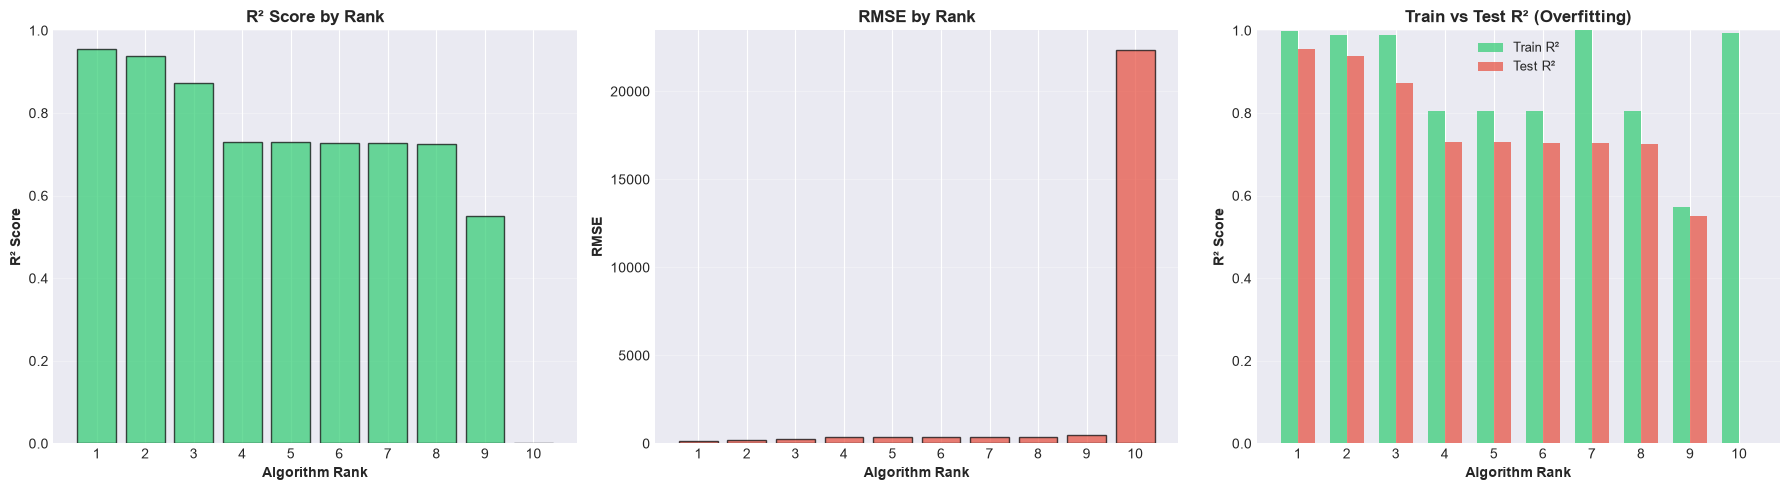

   ✅ Visualization displayed

✅ CELL 29 COMPLETE - ALL METRICS ANALYZED


In [33]:
print("\n" + "=" * 80)
print("CELL 29: ALGORITHM PERFORMANCE COMPARISON & ANALYSIS")
print("=" * 80)

import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize'] = (10, 5)

# Combine all results
results = [algo_1, algo_2, algo_3, algo_4, algo_5, algo_6, algo_7, algo_8, algo_9, algo_10]
results_df = pd.DataFrame(results)
results_df_sorted = results_df.sort_values('R2', ascending=False).reset_index(drop=True)

print("\n1️⃣ PERFORMANCE RANKING TABLE:\n")

ranking_table = results_df_sorted[['Algorithm', 'R2', 'RMSE', 'MAE', 'CV_R2', 'Train_R2']].copy()
ranking_table['Rank'] = range(1, len(ranking_table) + 1)
ranking_table = ranking_table[['Rank', 'Algorithm', 'R2', 'RMSE', 'MAE', 'CV_R2', 'Train_R2']]

print(ranking_table.to_string(index=False))

# ============================================================================
# RANKING BY DIFFERENT METRICS
# ============================================================================

print("\n\n2️⃣ RANKING BY DIFFERENT METRICS:\n")

print("🏆 BY R² SCORE (Highest is Better):")
print("─" * 70)
for idx, row in results_df.sort_values('R2', ascending=False).iterrows():
    print(f"   {row['Algorithm']:<35} R²: {row['R2']:.4f}")

print("\n🏆 BY RMSE (Lowest is Better):")
print("─" * 70)
for idx, row in results_df.sort_values('RMSE').head(5).iterrows():
    print(f"   {row['Algorithm']:<35} RMSE: {row['RMSE']:.4f}")

print("\n🏆 BY MAE (Lowest is Better):")
print("─" * 70)
for idx, row in results_df.sort_values('MAE').head(5).iterrows():
    print(f"   {row['Algorithm']:<35} MAE: {row['MAE']:.4f}")

print("\n🏆 BY CV_R² (Cross-Validation - Highest is Better):")
print("─" * 70)
for idx, row in results_df.sort_values('CV_R2', ascending=False).head(5).iterrows():
    print(f"   {row['Algorithm']:<35} CV_R²: {row['CV_R2']:.4f}")

# ============================================================================
# SUMMARY STATISTICS
# ============================================================================

print("\n\n3️⃣ SUMMARY STATISTICS:\n")

print(f"   R² SCORE:       Min: {results_df['R2'].min():.4f} | Max: {results_df['R2'].max():.4f} | Avg: {results_df['R2'].mean():.4f}")
print(f"   RMSE:           Min: {results_df['RMSE'].min():.4f} | Max: {results_df['RMSE'].max():.4f} | Avg: {results_df['RMSE'].mean():.4f}")
print(f"   MAE:            Min: {results_df['MAE'].min():.4f} | Max: {results_df['MAE'].max():.4f} | Avg: {results_df['MAE'].mean():.4f}")
print(f"   CV_R²:          Min: {results_df['CV_R2'].min():.4f} | Max: {results_df['CV_R2'].max():.4f} | Avg: {results_df['CV_R2'].mean():.4f}")

# ============================================================================
# OVERFITTING ANALYSIS
# ============================================================================

print("\n\n4️⃣ OVERFITTING ANALYSIS (Train_R² - Test_R²):\n")

results_df['Overfitting_Gap'] = results_df['Train_R2'] - results_df['R2']
gap_sorted = results_df.sort_values('Overfitting_Gap')

print("Algorithms with BEST generalization (Least Overfitting):")
print("─" * 70)
for idx, row in gap_sorted.head(3).iterrows():
    print(f"   {row['Algorithm']:<35} Gap: {row['Overfitting_Gap']:.4f}")

print("\nAlgorithms with POOR generalization (Most Overfitting):")
print("─" * 70)
for idx, row in gap_sorted.tail(3).iterrows():
    print(f"   {row['Algorithm']:<35} Gap: {row['Overfitting_Gap']:.4f}")

# ============================================================================
# KEY INSIGHTS
# ============================================================================

print("\n\n5️⃣ KEY INSIGHTS:\n")

best_algo = results_df_sorted.iloc[0]
worst_algo = results_df_sorted.iloc[-1]
best_rmse = results_df.loc[results_df['RMSE'].idxmin()]
best_mae = results_df.loc[results_df['MAE'].idxmin()]
least_overfit = results_df.loc[results_df['Overfitting_Gap'].idxmin()]
best_cv = results_df.loc[results_df['CV_R2'].idxmax()]

print(f"   🏆 Best R² Score:        {best_algo['Algorithm']} ({best_algo['R2']:.4f})")
print(f"   📊 Best RMSE (Accurate): {best_rmse['Algorithm']} ({best_rmse['RMSE']:.4f})")
print(f"   📈 Best MAE (Accurate):  {best_mae['Algorithm']} ({best_mae['MAE']:.4f})")
print(f"   🎯 Best Generalization:  {best_cv['Algorithm']} (CV_R²: {best_cv['CV_R2']:.4f})")
print(f"   ✅ Least Overfitting:    {least_overfit['Algorithm']} (Gap: {least_overfit['Overfitting_Gap']:.4f})")
print(f"   ⚠️  Worst Performer:     {worst_algo['Algorithm']} ({worst_algo['R2']:.4f})")

# ============================================================================
# SINGLE COMPACT VISUALIZATION
# ============================================================================

print("\n\n6️⃣ GENERATING COMPACT VISUALIZATION...\n")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# R² Comparison
r2_sorted = results_df.sort_values('R2', ascending=False)
axes[0].bar(range(len(r2_sorted)), r2_sorted['R2'].values, color='#2ecc71', alpha=0.7, edgecolor='black')
axes[0].set_xticks(range(len(r2_sorted)))
axes[0].set_xticklabels(range(1, len(r2_sorted)+1), fontsize=10)
axes[0].set_ylabel('R² Score', fontweight='bold')
axes[0].set_xlabel('Algorithm Rank', fontweight='bold')
axes[0].set_title('R² Score by Rank', fontweight='bold', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1])

# RMSE Comparison
rmse_sorted = results_df.sort_values('RMSE')
axes[1].bar(range(len(rmse_sorted)), rmse_sorted['RMSE'].values, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[1].set_xticks(range(len(rmse_sorted)))
axes[1].set_xticklabels(range(1, len(rmse_sorted)+1), fontsize=10)
axes[1].set_ylabel('RMSE', fontweight='bold')
axes[1].set_xlabel('Algorithm Rank', fontweight='bold')
axes[1].set_title('RMSE by Rank', fontweight='bold', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

# Train vs Test R²
x_pos = range(len(results_df_sorted))
width = 0.35
axes[2].bar([i - width/2 for i in x_pos], results_df_sorted['Train_R2'], width, label='Train R²', color='#2ecc71', alpha=0.7)
axes[2].bar([i + width/2 for i in x_pos], results_df_sorted['R2'], width, label='Test R²', color='#e74c3c', alpha=0.7)
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(range(1, len(results_df_sorted)+1), fontsize=10)
axes[2].set_ylabel('R² Score', fontweight='bold')
axes[2].set_xlabel('Algorithm Rank', fontweight='bold')
axes[2].set_title('Train vs Test R² (Overfitting)', fontweight='bold', fontsize=12)
axes[2].legend(fontsize=9)
axes[2].grid(axis='y', alpha=0.3)
axes[2].set_ylim([0, 1])

plt.tight_layout()
plt.show()
plt.close()

print("   ✅ Visualization displayed")

print("\n" + "=" * 80)
print("✅ CELL 29 COMPLETE - ALL METRICS ANALYZED")
print("=" * 80)